# 03 Topic Modelling: Melbourne Liveability YouTube Dataset

This notebook performs topic modelling on the cleaned YouTube comment corpus for the Melbourne liveability project.

## Objectives
1. Load the cleaned analysis comment subset.
2. Create a topic-modelling-ready document set.
3. Vectorise the text using a transparent bag-of-words representation.
4. Compare multiple candidate topic counts.
5. Select and fit a final topic model.
6. Extract top terms and representative comments for interpretation.
7. Compare topic prevalence across theme buckets and videos.
8. Save topic outputs for use in the report.

## Analytical aim
The purpose of this notebook is not just to produce a model, but to identify interpretable recurring themes in Melbourne liveability discussions and connect those themes back to the network and video-level structure established earlier.

In [123]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import LatentDirichletAllocation

In [ ]:
# Paths

BASE_DIR = Path(".")
OUTPUTS_DIR = BASE_DIR / "outputs"

COMMENTS_ANALYSIS_FILE = OUTPUTS_DIR / "melbourne_liveability_youtube_comments_analysis.csv"
VIDEO_SUMMARY_FILE = OUTPUTS_DIR / "melbourne_liveability_youtube_video_summary.csv"

TOPIC_TERMS_FILE = OUTPUTS_DIR / "melbourne_liveability_youtube_topic_terms.csv"
COMMENTS_WITH_TOPICS_FILE = OUTPUTS_DIR / "melbourne_liveability_youtube_comments_with_topics.csv"
TOPIC_PREVALENCE_BY_THEME_FILE = OUTPUTS_DIR / "melbourne_liveability_youtube_topic_prevalence_by_theme.csv"
TOPIC_PREVALENCE_BY_VIDEO_FILE = OUTPUTS_DIR / "melbourne_liveability_youtube_topic_prevalence_by_video.csv"
TOPIC_MODEL_SUMMARY_FILE = OUTPUTS_DIR / "melbourne_liveability_youtube_topic_model_summary.json"
TOPIC_REPRESENTATIVE_COMMENTS_FILE = OUTPUTS_DIR / "melbourne_liveability_youtube_topic_representative_comments.csv"

In [ ]:
# Load data

comments_analysis = pd.read_csv(COMMENTS_ANALYSIS_FILE)
video_summary = pd.read_csv(VIDEO_SUMMARY_FILE)

print("Loaded:")
print(f"Analysis comments: {len(comments_analysis):,}")
print(f"Video summary rows: {len(video_summary):,}")

Loaded:
Analysis comments: 7,195
Video summary rows: 26


In [126]:
comments_analysis.head(3)

,videoId,videoTitle,channelTitle,commentId,parentCommentId,isReply,authorChannelId,authorDisplayName,text,publishedAt,...,word_count,has_latin,is_very_short,theme_bucket,videoTitle_from_videos,videoChannelTitle_from_videos,videoPublishedAt,viewCount,videoLikeCount,commentCount
0,oUqavm7KhGg,What Is Livability? A Field Report from Melbourne,Ray Delahanty | CityNerd,UgxfkT1LGxwdKM1oC0Z4AaABAg,NaN,False,UCfgtNfWCtsLKutY-BHzIb9Q,@CityNerd,"Also, five stars for a streaming service that ...",2025-04-09T17:42:41Z,...,37,True,False,liveability_general,What Is Livability? A Field Report from Melbourne,Ray Delahanty | CityNerd,2025-04-09T16:38:51Z,235141,8853,1583
1,oUqavm7KhGg,What Is Livability? A Field Report from Melbourne,Ray Delahanty | CityNerd,UgxfkT1LGxwdKM1oC0Z4AaABAg.AGhWoANCHSUAGhfJLPlleO,UgxfkT1LGxwdKM1oC0Z4AaABAg,True,UC6qnEKpWuztXrUYjh4m8_SA,@Arandomguy892,You should come back to Australia some time an...,2025-04-09T19:05:43Z,...,85,True,False,liveability_general,What Is Livability? A Field Report from Melbourne,Ray Delahanty | CityNerd,2025-04-09T16:38:51Z,235141,8853,1583
2,oUqavm7KhGg,What Is Livability? A Field Report from Melbourne,Ray Delahanty | CityNerd,UgxfkT1LGxwdKM1oC0Z4AaABAg.AGhWoANCHSUAGjBRDzZThp,UgxfkT1LGxwdKM1oC0Z4AaABAg,True,UCLCN6Ivqz9S0IVaFOI4fdpw,@OriginalPiMan,@Arandomguy892 \nHe went to Sydney next; expec...,2025-04-10T09:14:23Z,...,12,True,False,liveability_general,What Is Livability? A Field Report from Melbourne,Ray Delahanty | CityNerd,2025-04-09T16:38:51Z,235141,8853,1583


## Topic-document subset

Although the cleaned analysis subset already removed very short and non-Latin comments, topic modelling generally benefits from slightly richer documents.

To improve topic stability, this notebook creates a narrower **topic-document subset** by keeping comments with at least 5 words. This is especially helpful because YouTube comments are often very short.

In [127]:
TOPIC_DOC_MIN_WORDS = 5

topic_docs = comments_analysis[
    comments_analysis["word_count"] >= TOPIC_DOC_MIN_WORDS
].copy()

print("Comments in analysis subset:", len(comments_analysis))
print("Comments retained for topic modelling:", len(topic_docs))
print("Comments excluded for being too short for topic modelling:", len(comments_analysis) - len(topic_docs))

Comments in analysis subset: 7195
Comments retained for topic modelling: 6683
Comments excluded for being too short for topic modelling: 512


In [128]:
topic_docs[["videoTitle", "theme_bucket", "text_clean", "word_count"]].sample(10, random_state=42)

,videoTitle,theme_bucket,text_clean,word_count
4620,But there’s a harbour! #australia #sydney #mel...,other,But the ice cream… 🤤,5
6437,How to get from Melbourne Airport to the CBD f...,transport_infrastructure,Thank you so much. I have question from where ...,13
1588,Should you live in Melbourne? Our HONEST thoughts,living_experience,Absolutely agree that Melbourne is one of the ...,28
6385,How To Use Public Transport in Melbourne | Usi...,transport_infrastructure,@Internash What if I do bachelor's in Geelong ?,9
6660,"The Comprehensive ""Metro"" Network of Melbourne",transport_infrastructure,YES! Make a Video about Melbourne trams! Also ...,23
6778,"The Comprehensive ""Metro"" Network of Melbourne",transport_infrastructure,Cool! Sounds like a fun video!,6
3560,Sydney and Melbourne Compared,city_comparison,Sydney has no night life. We've been locked ou...,13
2593,Sydney and Melbourne Compared,city_comparison,@JeSus-hl6zj Do you think I only follow things...,52
4193,But there’s a harbour! #australia #sydney #mel...,other,Came here to say this 😂 Vancouver = Melbourne ...,12
6799,"The Comprehensive ""Metro"" Network of Melbourne",transport_infrastructure,"Great video Reece. Out of interest, did you de...",17


## Vectorisation strategy

A count-based document-term matrix is used because:
- it is transparent and easy to interpret;
- it works naturally with LDA;
- it allows clear extraction of top words and phrases.

The vectoriser uses:
- unigrams and bigrams;
- document-frequency thresholds to remove very rare and overly common terms;
- a small domain-specific stopword list to prevent obvious corpus-wide words from dominating every topic.

In [129]:
DOMAIN_STOPWORDS = {
    "melbourne", "liveability", "livability", "australia", "australian",
    "video", "videos", "comment", "comments", "youtube",
    "just", "really", "like", "think", "know", "people"
}

CUSTOM_STOPWORDS = sorted(set(ENGLISH_STOP_WORDS).union(DOMAIN_STOPWORDS))

VECTORIZER_CONFIG = {
    "stop_words": CUSTOM_STOPWORDS,
    "ngram_range": (1, 2),
    "min_df": 10,
    "max_df": 0.60,
    "max_features": 5000,
    "token_pattern": r"(?u)\b[a-zA-Z][a-zA-Z]+\b"
}

vectorizer = CountVectorizer(**VECTORIZER_CONFIG)
X = vectorizer.fit_transform(topic_docs["text_clean"])

print("Document-term matrix shape:", X.shape)
print("Vocabulary size:", len(vectorizer.get_feature_names_out()))

Document-term matrix shape: (6683, 1736)
Vocabulary size: 1736


In [130]:
feature_names = vectorizer.get_feature_names_out()
feature_names[:50]

array(['able', 'absolute', 'absolutely', 'accent', 'access',
       'accessibility', 'accessible', 'according', 'accurate', 'actual',
       'actually', 'add', 'added', 'adding', 'adelaide', 'admit',
       'afford', 'affordable', 'afl', 'afl teams', 'africa', 'age',
       'ages', 'ago', 'agree', 'agreed', 'ahead', 'ain', 'air', 'airport',
       'airport line', 'airport rail', 'allow', 'alot', 'amazing',
       'america', 'american', 'americans', 'angeles', 'annoying',
       'answer', 'anti', 'anymore', 'apart', 'apartment', 'apartments',
       'app', 'apparently', 'appreciate', 'appreciated'], dtype=object)

## Candidate topic-count comparison

A stronger topic-modelling workflow compares multiple topic counts rather than locking into one value immediately.

Here, candidate models with 4, 6, and 8 topics are compared. Quantitative diagnostics such as perplexity are recorded, but final selection should also depend on interpretability.

In [131]:
def extract_topic_terms(model, feature_names, top_n=12):
    rows = []
    for topic_idx, topic_weights in enumerate(model.components_):
        top_idx = topic_weights.argsort()[::-1][:top_n]
        top_terms = [feature_names[i] for i in top_idx]
        rows.append({
            "topic_id": topic_idx,
            "top_terms": ", ".join(top_terms)
        })
    return pd.DataFrame(rows)

In [132]:
CANDIDATE_TOPIC_COUNTS = [4, 6, 8]

candidate_models = {}
candidate_eval_rows = []

for k in CANDIDATE_TOPIC_COUNTS:
    lda = LatentDirichletAllocation(
        n_components=k,
        random_state=42,
        learning_method="batch",
        max_iter=20
    )
    doc_topic = lda.fit_transform(X)

    avg_max_topic_prob = doc_topic.max(axis=1).mean()

    candidate_models[k] = {
        "model": lda,
        "doc_topic": doc_topic
    }

    candidate_eval_rows.append({
        "n_topics": k,
        "perplexity": lda.perplexity(X),
        "avg_max_topic_probability": avg_max_topic_prob
    })

candidate_eval = pd.DataFrame(candidate_eval_rows).sort_values("n_topics").reset_index(drop=True)
candidate_eval

,n_topics,perplexity,avg_max_topic_probability
0,4,981.446402,0.703756
1,6,992.529408,0.660014
2,8,1016.770319,0.629828


In [133]:
for k in CANDIDATE_TOPIC_COUNTS:
    print(f"\n{'='*70}")
    print(f"Candidate model: {k} topics")
    print(f"{'='*70}")
    display(extract_topic_terms(candidate_models[k]["model"], feature_names, top_n=12))


Candidate model: 4 topics


,topic_id,top_terms
0,0,"city, love, great, coffee, good, world, best, ..."
1,1,"sydney, better, live, years, weather, lived, c..."
2,2,"trains, sydney, train, line, tram, network, tr..."
3,3,"don, year, live, time, need, thanks, ve, new, ..."



Candidate model: 6 topics


,topic_id,top_terms
0,0,"city, love, great, world, best, free, sydney, ..."
1,1,"sydney, better, weather, years, live, city, li..."
2,2,"trains, train, sydney, line, tram, network, ra..."
3,3,"year, don, need, money, rent, afl, going, livi..."
4,4,"don, live, lol, country, cities, say, world, c..."
5,5,"thanks, good, time, coffee, hi, great, thank, ..."



Candidate model: 8 topics


,topic_id,top_terms
0,0,"city, great, love, suburbs, world, sydney, cit..."
1,1,"sydney, better, weather, city, live, cities, b..."
2,2,"trains, train, sydney, line, network, rail, me..."
3,3,"afl, say, right, trams, place, make, teams, ho..."
4,4,"don, lol, coffee, good, live, country, things,..."
5,5,"thanks, thank, time, hi, watching, great, judy..."
6,6,"year, don, live, rent, buy, pay, money, come, ..."
7,7,"years, ve, lived, sydney, best, ago, time, st,..."


## Select final topic count

After reviewing the quantitative diagnostics and the top-term outputs above, choose the final number of topics.

This cell uses a manually specified `CHOSEN_K` so the decision remains transparent and easy to revise.

In [134]:
CHOSEN_K = 6

In [135]:
final_lda = candidate_models[CHOSEN_K]["model"]
final_doc_topic = candidate_models[CHOSEN_K]["doc_topic"]

print(f"Chosen topic count: {CHOSEN_K}")
print(f"Perplexity: {final_lda.perplexity(X):.2f}")
print(f"Average max topic probability: {final_doc_topic.max(axis=1).mean():.4f}")

Chosen topic count: 6
Perplexity: 992.53
Average max topic probability: 0.6600


In [136]:
topic_terms = extract_topic_terms(final_lda, feature_names, top_n=15)
topic_terms

,topic_id,top_terms
0,0,"city, love, great, world, best, free, sydney, ..."
1,1,"sydney, better, weather, years, live, city, li..."
2,2,"trains, train, sydney, line, tram, network, ra..."
3,3,"year, don, need, money, rent, afl, going, livi..."
4,4,"don, live, lol, country, cities, say, world, c..."
5,5,"thanks, good, time, coffee, hi, great, thank, ..."


## Topic interpretation and cautious labelling

The model produces latent topics, not ready-made human categories. Labels should therefore be assigned cautiously and can be revised after checking:
- top terms
- representative comments
- prevalence across theme buckets and videos

In [137]:
topic_docs = topic_docs.copy()

topic_prob_cols = [f"topic_{i}_prob" for i in range(CHOSEN_K)]
topic_prob_df = pd.DataFrame(final_doc_topic, columns=topic_prob_cols, index=topic_docs.index)

topic_docs = pd.concat([topic_docs, topic_prob_df], axis=1)
topic_docs["dominant_topic"] = final_doc_topic.argmax(axis=1)
topic_docs["dominant_topic_probability"] = final_doc_topic.max(axis=1)

topic_docs[["text_clean", "dominant_topic", "dominant_topic_probability"]].head(10)

,text_clean,dominant_topic,dominant_topic_probability
0,"Also, five stars for a streaming service that ...",5,0.667626
1,You should come back to Australia some time an...,4,0.415455
2,@Arandomguy892 He went to Sydney next; expect ...,1,0.832390
3,They heard your rant “It seems Victoria's publ...,2,0.482292
4,Maybe you could find a grant that could allow ...,5,0.906507
5,Melbourne isn't the only city with trams. Adel...,2,0.464800
6,every time i look at Nebula I'm tempted by the...,0,0.571478
7,"@ ""gorgeous"" == ? liveable with C19th colonial...",0,0.582870
8,As an Australian and a person who lives in Vic...,3,0.817620
9,Ray: “I hate birds” Bird: “I don’t think about...,4,0.791514


In [138]:
TOPIC_LABEL_MAP = {
    0: "general_liveability_and_city_amenities",
    1: "city_comparison_weather_and_lifestyle",
    2: "public_transport_and_rail_infrastructure",
    3: "cost_of_living_rent_and_household_pressure",
    4: "argumentative_city_identity_debate",
    5: "creator_audience_conversational_replies"
}

topic_terms["topic_label"] = topic_terms["topic_id"].map(TOPIC_LABEL_MAP)
topic_docs["topic_label"] = topic_docs["dominant_topic"].map(TOPIC_LABEL_MAP)

topic_terms

,topic_id,top_terms,topic_label
0,0,"city, love, great, world, best, free, sydney, ...",general_liveability_and_city_amenities
1,1,"sydney, better, weather, years, live, city, li...",city_comparison_weather_and_lifestyle
2,2,"trains, train, sydney, line, tram, network, ra...",public_transport_and_rail_infrastructure
3,3,"year, don, need, money, rent, afl, going, livi...",cost_of_living_rent_and_household_pressure
4,4,"don, live, lol, country, cities, say, world, c...",argumentative_city_identity_debate
5,5,"thanks, good, time, coffee, hi, great, thank, ...",creator_audience_conversational_replies


In [139]:
rep_comments = (
    topic_docs.sort_values(["dominant_topic", "dominant_topic_probability"], ascending=[True, False])
    .groupby("dominant_topic")
    .head(8)
    .copy()
)

rep_comments["topic_label"] = rep_comments["dominant_topic"].map(TOPIC_LABEL_MAP)

## Overall topic prevalence

Two complementary views are useful:
1. **dominant-topic counts** — how often each topic is the most probable topic in a comment;
2. **mean topic probabilities** — how much the corpus leans toward each topic on average.

In [140]:
overall_topic_counts = (
    topic_docs["dominant_topic"]
    .value_counts()
    .sort_index()
    .rename_axis("topic_id")
    .reset_index(name="dominant_comment_count")
)

overall_topic_counts["topic_label"] = overall_topic_counts["topic_id"].map(TOPIC_LABEL_MAP)

overall_topic_probability = pd.DataFrame({
    "topic_id": list(range(CHOSEN_K)),
    "mean_topic_probability": final_doc_topic.mean(axis=0)
})
overall_topic_probability["topic_label"] = overall_topic_probability["topic_id"].map(TOPIC_LABEL_MAP)

overall_topic_counts

,topic_id,dominant_comment_count,topic_label
0,0,842,general_liveability_and_city_amenities
1,1,1556,city_comparison_weather_and_lifestyle
2,2,1058,public_transport_and_rail_infrastructure
3,3,1099,cost_of_living_rent_and_household_pressure
4,4,1077,argumentative_city_identity_debate
5,5,1051,creator_audience_conversational_replies


In [141]:
overall_topic_probability

,topic_id,mean_topic_probability,topic_label
0,0,0.131113,general_liveability_and_city_amenities
1,1,0.216515,city_comparison_weather_and_lifestyle
2,2,0.162959,public_transport_and_rail_infrastructure
3,3,0.166229,cost_of_living_rent_and_household_pressure
4,4,0.164184,argumentative_city_identity_debate
5,5,0.158999,creator_audience_conversational_replies


In [142]:


SHORT_TOPIC_LABELS = {
    "general_liveability_and_city_amenities": "General liveability",
    "city_comparison_weather_and_lifestyle": "City comparison",
    "public_transport_and_rail_infrastructure": "Transport",
    "cost_of_living_rent_and_household_pressure": "Cost of living",
    "argumentative_city_identity_debate": "Identity debate",
    "creator_audience_conversational_replies": "Creator replies"
}

TOPIC_ORDER = [
    "General liveability",
    "City comparison",
    "Transport",
    "Cost of living",
    "Identity debate",
    "Creator replies"
]

THEME_BUCKET_ORDER = [
    "liveability_general",
    "living_experience",
    "cost_housing",
    "transport_infrastructure",
    "city_comparison",
    "other"
]

THEME_BUCKET_LABELS = {
    "liveability_general": "Liveability general",
    "living_experience": "Living experience",
    "cost_housing": "Cost / housing",
    "transport_infrastructure": "Transport / infrastructure",
    "city_comparison": "City comparison",
    "other": "Other"
}

def shorten_video_title(title, max_len=42):
    title = str(title)
    title = title.replace("_", " ")
    title = " ".join(title.split())
    return title if len(title) <= max_len else title[:max_len - 3] + "..."

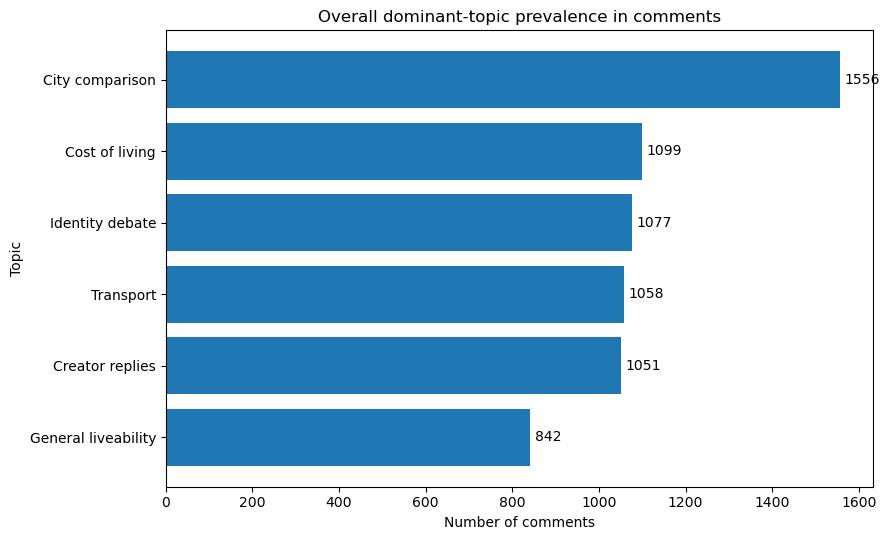

In [156]:
# Final Figure 1 — Overall dominant-topic prevalence
# Horizontal bar chart with short labels


plot_df = overall_topic_counts.copy()

plot_df["topic_label_short"] = plot_df["topic_label"].map(SHORT_TOPIC_LABELS)
plot_df = plot_df.sort_values("dominant_comment_count", ascending=True)

plt.figure(figsize=(9, 5.5))
bars = plt.barh(plot_df["topic_label_short"], plot_df["dominant_comment_count"])

plt.xlabel("Number of comments")
plt.ylabel("Topic")
plt.title("Overall dominant-topic prevalence in comments")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 10,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va="center"
    )

plt.tight_layout()
plt.savefig(
    OUTPUTS_DIR / "figure_topic_overall_dominant_prevalence.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Topic prevalence by theme bucket

This is one of the most important sections for interpretation.

It allows us to compare how topic structure varies across broad liveability dimensions such as:
- general liveability
- cost and housing
- transport and infrastructure
- city comparison
- lived experience

In [157]:
# Mean topic probability by theme bucket
theme_topic_prob = (
    topic_docs.groupby("theme_bucket")[topic_prob_cols]
    .mean()
    .reset_index()
)

theme_topic_prob.columns = ["theme_bucket"] + [f"topic_{i}" for i in range(CHOSEN_K)]
theme_topic_prob

,theme_bucket,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5
0,city_comparison,0.151745,0.289253,0.064340,0.158797,0.217549,0.118316
1,cost_housing,0.106027,0.199840,0.061063,0.296131,0.134739,0.202200
2,liveability_general,0.135492,0.140998,0.245678,0.170476,0.142718,0.164638
3,living_experience,0.147200,0.236720,0.060410,0.122982,0.166497,0.266190
4,other,0.164886,0.294441,0.061629,0.118335,0.218991,0.141719
5,transport_infrastructure,0.092382,0.103789,0.469545,0.120092,0.094057,0.120135


In [158]:
theme_topic_long = theme_topic_prob.melt(
    id_vars="theme_bucket",
    var_name="topic_col",
    value_name="mean_topic_probability"
)

theme_topic_long["topic_id"] = theme_topic_long["topic_col"].str.extract(r"(\d+)").astype(int)
theme_topic_long["topic_label"] = theme_topic_long["topic_id"].map(TOPIC_LABEL_MAP)

theme_topic_long.head()

,theme_bucket,topic_col,mean_topic_probability,topic_id,topic_label
0,city_comparison,topic_0,0.151745,0,general_liveability_and_city_amenities
1,cost_housing,topic_0,0.106027,0,general_liveability_and_city_amenities
2,liveability_general,topic_0,0.135492,0,general_liveability_and_city_amenities
3,living_experience,topic_0,0.147200,0,general_liveability_and_city_amenities
4,other,topic_0,0.164886,0,general_liveability_and_city_amenities


In [159]:
# Pivot for stacked plotting
theme_topic_plot = (
    theme_topic_long.pivot(index="theme_bucket", columns="topic_label", values="mean_topic_probability")
    .fillna(0)
)

theme_topic_plot

topic_label,argumentative_city_identity_debate,city_comparison_weather_and_lifestyle,cost_of_living_rent_and_household_pressure,creator_audience_conversational_replies,general_liveability_and_city_amenities,public_transport_and_rail_infrastructure
theme_bucket,,,,,,
city_comparison,0.217549,0.289253,0.158797,0.118316,0.151745,0.064340
cost_housing,0.134739,0.199840,0.296131,0.202200,0.106027,0.061063
liveability_general,0.142718,0.140998,0.170476,0.164638,0.135492,0.245678
living_experience,0.166497,0.236720,0.122982,0.266190,0.147200,0.060410
other,0.218991,0.294441,0.118335,0.141719,0.164886,0.061629
transport_infrastructure,0.094057,0.103789,0.120092,0.120135,0.092382,0.469545


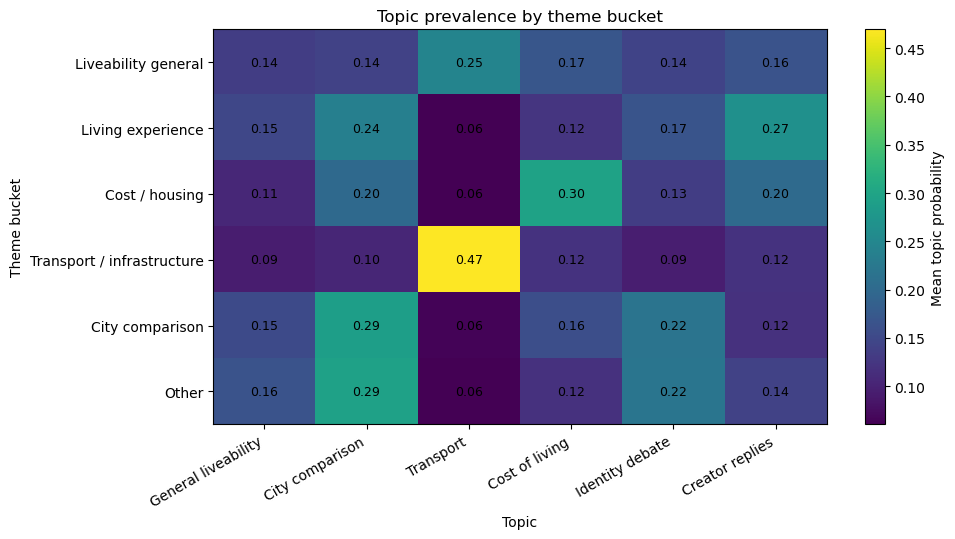

In [160]:

# Final Figure 2 — Topic prevalence by theme bucket
# Heatmap version


theme_topic_plot = (
    theme_topic_long.copy()
)

theme_topic_plot["topic_label_short"] = theme_topic_plot["topic_label"].map(SHORT_TOPIC_LABELS)
theme_topic_plot["theme_bucket_short"] = theme_topic_plot["theme_bucket"].map(THEME_BUCKET_LABELS)

heatmap_df = (
    theme_topic_plot.pivot(
        index="theme_bucket_short",
        columns="topic_label_short",
        values="mean_topic_probability"
    )
    .reindex(index=[THEME_BUCKET_LABELS[x] for x in THEME_BUCKET_ORDER if x in theme_topic_plot["theme_bucket"].unique()])
    .reindex(columns=TOPIC_ORDER)
)

fig, ax = plt.subplots(figsize=(10, 5.5))
im = ax.imshow(heatmap_df.values, aspect="auto")

ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns, rotation=30, ha="right")
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)

ax.set_title("Topic prevalence by theme bucket")
ax.set_xlabel("Topic")
ax.set_ylabel("Theme bucket")

for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        val = heatmap_df.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Mean topic probability")

plt.tight_layout()
plt.savefig(
    OUTPUTS_DIR / "figure_topic_prevalence_by_theme_bucket_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Topic prevalence by video

To avoid clutter, the comparison below is limited to the most-commented videos in the topic-document subset.

In [161]:
top_video_ids = (
    topic_docs["videoId"]
    .value_counts()
    .head(10)
    .index
)

topic_docs_top_videos = topic_docs[topic_docs["videoId"].isin(top_video_ids)].copy()

video_topic_prob = (
    topic_docs_top_videos.groupby(["videoId", "videoTitle"])[topic_prob_cols]
    .mean()
    .reset_index()
)

video_topic_prob.head()

,videoId,videoTitle,topic_0_prob,topic_1_prob,topic_2_prob,topic_3_prob,topic_4_prob,topic_5_prob
0,AbtyFah6fPY,"Melbourne, Australia 🇦🇺 - The Most Livable Cit...",0.226623,0.143635,0.060476,0.134946,0.260864,0.173456
1,FSOnKtQa-j8,Does Sydney have better public transport than ...,0.079115,0.117039,0.528402,0.099835,0.085371,0.090237
2,HRP1t-P0Ljw,Starving to pay rent: The brutal reality of th...,0.061472,0.076568,0.063041,0.516360,0.169442,0.113116
3,MzgZV6CKDL4,But there’s a harbour! #australia #sydney #mel...,0.140433,0.343641,0.062912,0.105301,0.222200,0.125512
4,aUJBIrElRSk,🇦🇺 What Makes MELBOURNE Better Than SYDNEY In ...,0.128197,0.481301,0.051722,0.112897,0.130582,0.095301


In [162]:
video_topic_long = video_topic_prob.melt(
    id_vars=["videoId", "videoTitle"],
    var_name="topic_col",
    value_name="mean_topic_probability"
)

video_topic_long["topic_id"] = video_topic_long["topic_col"].str.extract(r"(\d+)").astype(int)
video_topic_long["topic_label"] = video_topic_long["topic_id"].map(TOPIC_LABEL_MAP)

video_topic_long.head()

,videoId,videoTitle,topic_col,mean_topic_probability,topic_id,topic_label
0,AbtyFah6fPY,"Melbourne, Australia 🇦🇺 - The Most Livable Cit...",topic_0_prob,0.226623,0,general_liveability_and_city_amenities
1,FSOnKtQa-j8,Does Sydney have better public transport than ...,topic_0_prob,0.079115,0,general_liveability_and_city_amenities
2,HRP1t-P0Ljw,Starving to pay rent: The brutal reality of th...,topic_0_prob,0.061472,0,general_liveability_and_city_amenities
3,MzgZV6CKDL4,But there’s a harbour! #australia #sydney #mel...,topic_0_prob,0.140433,0,general_liveability_and_city_amenities
4,aUJBIrElRSk,🇦🇺 What Makes MELBOURNE Better Than SYDNEY In ...,topic_0_prob,0.128197,0,general_liveability_and_city_amenities


In [163]:
video_topic_plot = (
    video_topic_long.pivot(index="videoTitle", columns="topic_label", values="mean_topic_probability")
    .fillna(0)
)

video_topic_plot

topic_label,argumentative_city_identity_debate,city_comparison_weather_and_lifestyle,cost_of_living_rent_and_household_pressure,creator_audience_conversational_replies,general_liveability_and_city_amenities,public_transport_and_rail_infrastructure
videoTitle,,,,,,
But there’s a harbour! #australia #sydney #melbourne #sydneylife #melbournecity,0.222200,0.343641,0.105301,0.125512,0.140433,0.062912
Does Sydney have better public transport than Melbourne? (ft. Philip Mallis),0.085371,0.117039,0.099835,0.090237,0.079115,0.528402
"Melbourne, Australia 🇦🇺 - The Most Livable City in the World? | Victoria, Australia Travel Guide",0.260864,0.143635,0.134946,0.173456,0.226623,0.060476
Should you live in Melbourne? | Pros and cons of living in Melbourne,0.135071,0.242563,0.102194,0.314829,0.147435,0.057908
Starving to pay rent: The brutal reality of the cost of living crisis | 60 Minutes Australia,0.169442,0.076568,0.516360,0.113116,0.061472,0.063041
Sydney and Melbourne Compared,0.241958,0.235351,0.171680,0.124776,0.158354,0.067881
"The Comprehensive ""Metro"" Network of Melbourne",0.109914,0.076501,0.090578,0.177053,0.127991,0.417964
What Is Livability? A Field Report from Melbourne,0.142922,0.141200,0.170737,0.163369,0.135681,0.246091
Why Melbourne Feels Different Than Sydney,0.087923,0.324098,0.100961,0.308472,0.127732,0.050815


/var/folders/gh/bwj1rj5s4h34m3kzg_xqph_m0000gn/T/ipykernel_48318/3315682357.py:57: UserWarning: Glyph 127462 (\N{REGIONAL INDICATOR SYMBOL LETTER A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/gh/bwj1rj5s4h34m3kzg_xqph_m0000gn/T/ipykernel_48318/3315682357.py:57: UserWarning: Glyph 127482 (\N{REGIONAL INDICATOR SYMBOL LETTER U}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/gh/bwj1rj5s4h34m3kzg_xqph_m0000gn/T/ipykernel_48318/3315682357.py:58: UserWarning: Glyph 127462 (\N{REGIONAL INDICATOR SYMBOL LETTER A}) missing from font(s) DejaVu Sans.
  plt.savefig(
/var/folders/gh/bwj1rj5s4h34m3kzg_xqph_m0000gn/T/ipykernel_48318/3315682357.py:58: UserWarning: Glyph 127482 (\N{REGIONAL INDICATOR SYMBOL LETTER U}) missing from font(s) DejaVu Sans.
  plt.savefig(
/opt/anaconda3/envs/projectFlask/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127462 (\N{REGIONAL INDICATOR SYMBOL LETTER A}) missing from font(s) DejaVu San

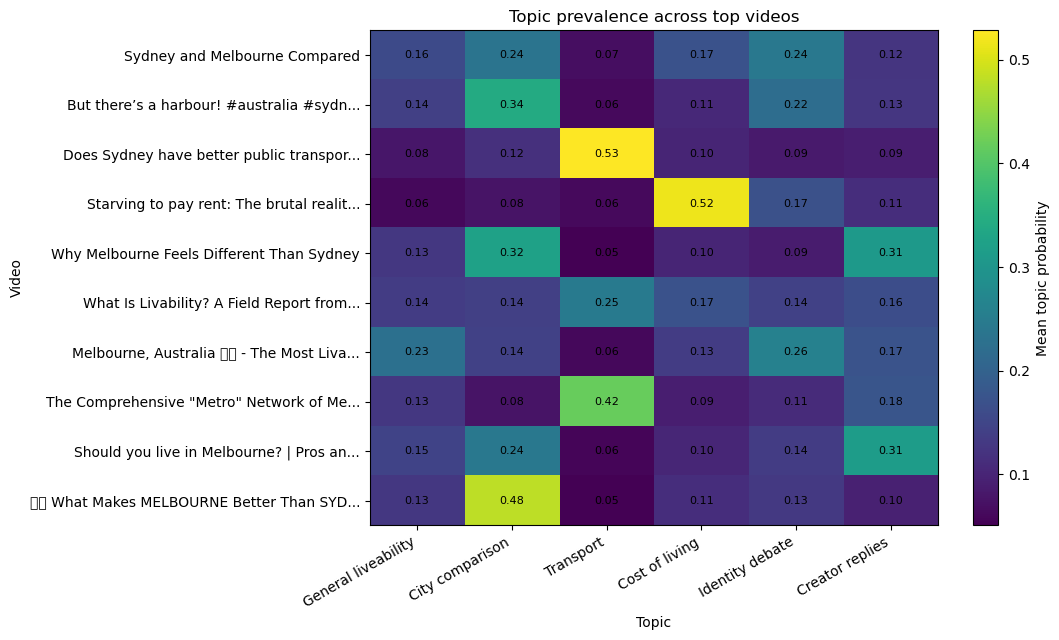

In [164]:

# Final Figure 3 — Topic prevalence across top videos
# Heatmap version


video_topic_plot = video_topic_long.copy()

video_topic_plot["topic_label_short"] = video_topic_plot["topic_label"].map(SHORT_TOPIC_LABELS)
video_topic_plot["videoTitle_short"] = video_topic_plot["videoTitle"].apply(shorten_video_title)

# Preserve ordering by comment volume from the original top-video selection
video_order = (
    topic_docs["videoId"]
    .value_counts()
    .head(10)
    .index
)

video_order_titles = (
    topic_docs.loc[topic_docs["videoId"].isin(video_order), ["videoId", "videoTitle"]]
    .drop_duplicates()
    .set_index("videoId")
    .loc[video_order, "videoTitle"]
    .apply(shorten_video_title)
    .tolist()
)

video_heatmap_df = (
    video_topic_plot.pivot(
        index="videoTitle_short",
        columns="topic_label_short",
        values="mean_topic_probability"
    )
    .reindex(index=video_order_titles)
    .reindex(columns=TOPIC_ORDER)
)

fig, ax = plt.subplots(figsize=(11, 6.5))
im = ax.imshow(video_heatmap_df.values, aspect="auto")

ax.set_xticks(range(len(video_heatmap_df.columns)))
ax.set_xticklabels(video_heatmap_df.columns, rotation=30, ha="right")
ax.set_yticks(range(len(video_heatmap_df.index)))
ax.set_yticklabels(video_heatmap_df.index)

ax.set_title("Topic prevalence across top videos")
ax.set_xlabel("Topic")
ax.set_ylabel("Video")

for i in range(video_heatmap_df.shape[0]):
    for j in range(video_heatmap_df.shape[1]):
        val = video_heatmap_df.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Mean topic probability")

plt.tight_layout()
plt.savefig(
    OUTPUTS_DIR / "figure_topic_prevalence_across_top_videos_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [165]:
# Clean tables for appendix / report drafting


overall_topic_counts_report = overall_topic_counts.copy()
overall_topic_counts_report["topic_label"] = overall_topic_counts_report["topic_label"].map(SHORT_TOPIC_LABELS)

theme_topic_report = heatmap_df.round(3)
video_topic_report = video_heatmap_df.round(3)

overall_topic_counts_report.to_csv(
    OUTPUTS_DIR / "table_overall_topic_counts_report.csv",
    index=False,
    encoding="utf-8-sig"
)

theme_topic_report.to_csv(
    OUTPUTS_DIR / "table_topic_prevalence_by_theme_bucket_report.csv",
    encoding="utf-8-sig"
)

video_topic_report.to_csv(
    OUTPUTS_DIR / "table_topic_prevalence_across_top_videos_report.csv",
    encoding="utf-8-sig"
)

overall_topic_counts_report

,topic_id,dominant_comment_count,topic_label
0,0,842,General liveability
1,1,1556,City comparison
2,2,1058,Transport
3,3,1099,Cost of living
4,4,1077,Identity debate
5,5,1051,Creator replies


## Save outputs

In [166]:
rep_comments = rep_comments.copy()
rep_comments["topic_label"] = rep_comments["dominant_topic"].map(TOPIC_LABEL_MAP)

rep_comments[[
    "dominant_topic", "topic_label", "dominant_topic_probability",
    "theme_bucket", "videoTitle", "text_clean"
]].head()

,dominant_topic,topic_label,dominant_topic_probability,theme_bucket,videoTitle,text_clean
531,0,general_liveability_and_city_amenities,0.974539,other,"Melbourne, Australia 🇦🇺 - The Most Livable Cit...","my MEMORY in ""Melbourne"" weren't as Great as b..."
2552,0,general_liveability_and_city_amenities,0.969997,city_comparison,Sydney and Melbourne Compared,@timothyjennings9520 I think the point is that...
444,0,general_liveability_and_city_amenities,0.960066,liveability_general,What Is Livability? A Field Report from Melbourne,Best sporting city in the world. Huge stadiums...
987,0,general_liveability_and_city_amenities,0.947771,other,"Melbourne, Australia 🇦🇺 - The Most Livable Cit...",@stuartfarrow2338 ​ of COURSE👍👍WHY Whinge and ...
70,0,general_liveability_and_city_amenities,0.947643,liveability_general,What Is Livability? A Field Report from Melbourne,Yeah everything in an Australian city is a sub...


In [167]:
# Save topic terms
topic_terms.to_csv(TOPIC_TERMS_FILE, index=False, encoding="utf-8-sig")

# Save comments with dominant topic + probabilities
topic_docs.to_csv(COMMENTS_WITH_TOPICS_FILE, index=False, encoding="utf-8-sig")

# Save theme-bucket prevalence
theme_topic_long.to_csv(TOPIC_PREVALENCE_BY_THEME_FILE, index=False, encoding="utf-8-sig")

# Save video prevalence
video_topic_long.to_csv(TOPIC_PREVALENCE_BY_VIDEO_FILE, index=False, encoding="utf-8-sig")

# Save representative comments
rep_comments[[
    "dominant_topic", "topic_label", "dominant_topic_probability",
    "theme_bucket", "videoTitle", "text_clean"
]].to_csv(TOPIC_REPRESENTATIVE_COMMENTS_FILE, index=False, encoding="utf-8-sig")

topic_model_summary = {
    "analysis_comments_rows": int(len(comments_analysis)),
    "topic_docs_rows": int(len(topic_docs)),
    "topic_doc_min_words": int(TOPIC_DOC_MIN_WORDS),
    "document_term_matrix_shape": [int(X.shape[0]), int(X.shape[1])],
    "candidate_topic_counts": [int(k) for k in CANDIDATE_TOPIC_COUNTS],
    "candidate_eval": candidate_eval.to_dict(orient="records"),
    "chosen_k": int(CHOSEN_K),
    "chosen_model_perplexity": float(final_lda.perplexity(X)),
    "chosen_model_avg_max_topic_probability": float(final_doc_topic.max(axis=1).mean())
}

with open(TOPIC_MODEL_SUMMARY_FILE, "w", encoding="utf-8") as f:
    json.dump(topic_model_summary, f, ensure_ascii=False, indent=2)

topic_model_summary

{'analysis_comments_rows': 7195,
 'topic_docs_rows': 6683,
 'topic_doc_min_words': 5,
 'document_term_matrix_shape': [6683, 1736],
 'candidate_topic_counts': [4, 6, 8],
 'candidate_eval': [{'n_topics': 4,
   'perplexity': 981.4464019908007,
   'avg_max_topic_probability': 0.7037561633025629},
  {'n_topics': 6,
   'perplexity': 992.5294075880877,
   'avg_max_topic_probability': 0.6600142042253094},
  {'n_topics': 8,
   'perplexity': 1016.7703191725391,
   'avg_max_topic_probability': 0.6298277042193751}],
 'chosen_k': 6,
 'chosen_model_perplexity': 992.5294075880877,
 'chosen_model_avg_max_topic_probability': 0.6600142042253094}

## Preliminary interpretation

This section converts the model outputs into report-ready notes.

Do not over-claim. Topic models identify recurring lexical patterns, not perfect ground-truth categories.

In [168]:
print("Topic modelling complete.\n")

print("Candidate model comparison:")
print(candidate_eval.to_string(index=False))

print("\nFinal topic terms:")
print(topic_terms[["topic_id", "topic_label", "top_terms"]].to_string(index=False))

print("\nOverall dominant-topic counts:")
print(overall_topic_counts[["topic_id", "topic_label", "dominant_comment_count"]].to_string(index=False))

print("\nRepresentative comments by topic:")
print(
    rep_comments[["dominant_topic", "topic_label", "dominant_topic_probability", "theme_bucket", "text_clean"]]
    .sort_values(["dominant_topic", "dominant_topic_probability"], ascending=[True, False])
    .to_string(index=False)
)

Topic modelling complete.

Candidate model comparison:
 n_topics  perplexity  avg_max_topic_probability
        4  981.446402                   0.703756
        6  992.529408                   0.660014
        8 1016.770319                   0.629828

Final topic terms:
 topic_id                                topic_label                                                                                                          top_terms
        0     general_liveability_and_city_amenities             city, love, great, world, best, free, sydney, beautiful, cities, place, mcg, amazing, look, got, visit
        1      city_comparison_weather_and_lifestyle        sydney, better, weather, years, live, city, lived, beaches, cities, brisbane, great, beach, time, perth, ve
        2   public_transport_and_rail_infrastructure      trains, train, sydney, line, tram, network, rail, metro, trams, bus, station, airport, city, transport, lines
        3 cost_of_living_rent_and_household_pressure     

### Preliminary conclusion

The topic modelling workflow now supports the report in four ways:

1. it compares multiple candidate topic counts rather than assuming a single fixed number;
2. it produces interpretable top-term outputs for each topic;
3. it allows comments to be linked back to dominant topics and representative examples;
4. it compares topic prevalence across theme buckets and videos, helping answer how Melbourne liveability is framed differently across the corpus.

After inspecting the top terms and representative comments, the placeholder topic labels should be replaced with more meaningful labels before the final report is written.